In [ ]:
!pip install -q country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from gensim.parsing.preprocessing import *
import os
import time
import random as rd
import country_converter as coco
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.under_sampling import RandomUnderSampler
import pickle
from nltk.tokenize import word_tokenize

nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('punkt')
sns.set_style("whitegrid")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Chạy trước (*)

In [ ]:
# Chọn thư mục hoạt động

HOME = '/content/drive/MyDrive/AI/NLP'

!mkdir -p {HOME}
%cd {HOME}

/content/drive/MyDrive/AI/NLP


In [ ]:
# Tạo các thư mục liên quan

!rm -rf models/disneyland_reviews/
!rm -rf imgs/disneyland_reviews/
!rm -rf logs/disneyland_reviews/

!mkdir -p datasets/disneyland_reviews/
!mkdir -p models/disneyland_reviews/
!mkdir -p imgs/disneyland_reviews/
!mkdir -p logs/disneyland_reviews/

In [ ]:
# Thiết lập đường dẫn

ds_path = 'datasets/disneyland_reviews/'
model_path = 'models/disneyland_reviews/'
img_path = 'imgs/disneyland_reviews/'
log_path = 'logs/disneyland_reviews/'

In [ ]:
# Nạp API key Kaggle

!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp ../api_keys/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Tải tập dữ liệu từ Kaggle

import kaggle as kg

kg.api.dataset_download_files(
    'arushchillar/disneyland-reviews',
    path=ds_path,
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews


In [ ]:
# Liệt kê danh sách tệp

!ls {ds_path}

DisneylandReviews.csv


# Nạp dữ liệu

In [ ]:
# Nạp dữ liệu vào bộ nhớ

df = pd.read_csv(os.path.join(ds_path, 'DisneylandReviews.csv'), delimiter=',', encoding='latin1')
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
# Liệt kê các thuộc tính

df.columns

Index(['Review_ID', 'Rating', 'Year_Month', 'Reviewer_Location', 'Review_Text',
       'Branch'],
      dtype='object')

In [ ]:
# Khái quát sơ lược dữ liệu

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42656 entries, 0 to 42655
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Review_ID          42656 non-null  int64 
 1   Rating             42656 non-null  int64 
 2   Year_Month         42656 non-null  object
 3   Reviewer_Location  42656 non-null  object
 4   Review_Text        42656 non-null  object
 5   Branch             42656 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.0+ MB


# Tiền xử lý dữ liệu (1)


In [ ]:
# Kiểm tra & loại bỏ giá trị N/A (nếu có)

print(df.isna().sum())
df.dropna(inplace=True)

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64


In [ ]:
# Tiền xử lý thuộc tính Year_Month

## Kiểm tra giá trị duy nhẩt
print(df['Year_Month'].unique())

## Loại bỏ các trường dữ liệu có date bị miss
df = df[df['Year_Month'] != 'missing']

## Sửa lại định dạng datetime để convert cho chính xác
def fix_year_month(year_month):
    if not isinstance(year_month, str):
      return year_month
    year_month = year_month.split('-')
    month = year_month[1]
    year = year_month[0]
    if len(year) == 2:
        year = '20' + year
    if len(month) == 1:
        month = '0' + month
    return year + '-' + month

df['Year_Month'] = df['Year_Month'].apply(fix_year_month)
df['Year_Month'] = pd.to_datetime(df['Year_Month'], format='%Y-%m')
df.head(5)

['2019-4' '2019-5' '2019-3' '2018-9' '2019-1' '2018-11' '2018-12' '2018-6'
 '2019-2' '2018-10' '2018-8' '2018-5' '2018-4' '2018-7' '2018-3' '2018-2'
 'missing' '2018-1' '2017-12' '2017-11' '2017-6' '2017-10' '2017-9'
 '2017-8' '2017-7' '2017-5' '2017-4' '2017-3' '2017-2' '2017-1' '2016-12'
 '2016-11' '2016-10' '2016-9' '2016-8' '2016-7' '2016-6' '2016-5' '2016-4'
 '2016-3' '2016-2' '2016-1' '2015-12' '2015-11' '2015-10' '2015-9'
 '2015-8' '2015-7' '2015-6' '2015-5' '2015-4' '2015-3' '2015-2' '2015-1'
 '2014-12' '2014-11' '2014-10' '2014-9' '2014-8' '2014-7' '2014-6'
 '2014-5' '2014-4' '2014-3' '2014-2' '2014-1' '2013-12' '2013-11'
 '2013-10' '2013-9' '2013-8' '2013-7' '2013-6' '2013-5' '2013-4' '2013-3'
 '2013-2' '2013-1' '2012-12' '2012-11' '2012-10' '2012-9' '2012-8'
 '2012-7' '2012-6' '2012-5' '2012-4' '2012-3' '2012-2' '2012-1' '2011-12'
 '2011-11' '2011-10' '2011-9' '2011-8' '2011-7' '2011-6' '2011-5' '2011-4'
 '2011-3' '2011-2' '2011-1' '2010-12' '2010-11' '2010-10' '2010-9'
 '20

<ipython-input-13-ed19e6fe4d8a>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year_Month'] = df['Year_Month'].apply(fix_year_month)
<ipython-input-13-ed19e6fe4d8a>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year_Month'] = pd.to_datetime(df['Year_Month'], format='%Y-%m')


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-04-01,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-05-01,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-04-01,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-04-01,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-04-01,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [ ]:
# Tiền xử lý thuộc tính Reviewer_Location

## Liệt kê các giá trị duy nhất
print(df['Reviewer_Location'].unique())

## Chuyển đổi về chuẩn ISO3 cho đồng nhất
cc = coco.CountryConverter()
df['Reviewer_Location'] = cc.pandas_convert(series=df['Reviewer_Location'], to='ISO3')
df['Reviewer_Location'].head(3)

['Australia' 'Philippines' 'United Arab Emirates' 'United Kingdom'
 'Singapore' 'India' 'Malaysia' 'United States' 'Canada' 'Myanmar (Burma)'
 'Hong Kong' 'China' 'Indonesia' 'Qatar' 'New Zealand' 'Sri Lanka'
 'Uganda' 'Thailand' 'Austria' 'South Africa' 'Saudi Arabia' 'Japan'
 'Israel' 'South Korea' 'Turkey' 'Macau' 'Egypt' 'Mexico' 'Mauritius'
 'Sweden' 'Brazil' 'Kenya' 'Vietnam' 'Portugal' 'Cambodia' 'Zambia'
 'Croatia' 'France' 'Taiwan' 'Oman' 'Colombia' 'Norway' 'Kuwait'
 'Netherlands' 'Barbados' 'Finland' 'Bosnia and Herzegovina' 'Brunei'
 'Bahrain' 'Maldives' 'Ireland' 'Russia' 'Romania'
 'Northern Mariana Islands' 'Germany' 'Chile' 'Isle of Man' 'Pakistan'
 'Ukraine' 'Greece' 'Switzerland' 'Spain' 'Estonia' "Côte d'Ivoire" 'Guam'
 'Bangladesh' 'Belgium' 'Italy' 'Botswana' 'Denmark' 'Argentina' 'Peru'
 'Lithuania' 'Iran' 'Mali' 'Uruguay' 'Mongolia' 'Zimbabwe' 'Seychelles'
 'Puerto Rico' 'Hungary' 'Fiji' 'Nepal' 'Jordan' 'Cyprus' 'Venezuela'
 'Dominican Republic' 'Czechia' 'Bulga

<ipython-input-14-c8e2150d3f78>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reviewer_Location'] = cc.pandas_convert(series=df['Reviewer_Location'], to='ISO3')


,Reviewer_Location
0,AUS
1,PHL
2,ARE


In [ ]:
# Tiền xử lý thuộc tính Branch

## Liệt kê các giá trị duy nhất
df['Branch'].unique()

array(['Disneyland_HongKong', 'Disneyland_California', 'Disneyland_Paris'],
      dtype=object)

In [ ]:
# Tiền xử lý thuộc tính Rating

## Liệt kê các giá trị duy nhất
df['Rating'].unique()

array([4, 3, 5, 2, 1])

# Trực quan hóa dữ liệu

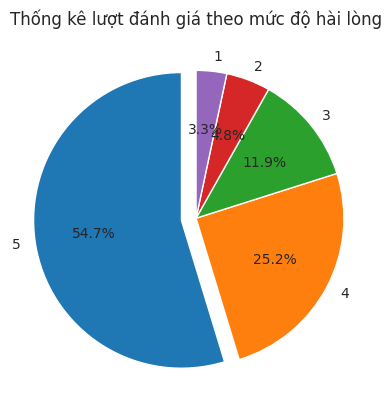

=> Disneyland có lượt đánh giá ở mức độ Hài lòng -> Rất hài lòng là nhiều nhất. 
Khách hàng có nhiều trải nghiệm tuyệt vời tại Disneyland ở cả 3 chi nhánh


In [ ]:
# Thống kê lượt đánh giá theo mức độ hài lòng

rating_counts = df['Rating'].value_counts()
labels = rating_counts.index
sizes = rating_counts.values
explode = (0.1, 0, 0, 0, 0)  # explode the 5-star slice

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
shadow=False, startangle=90)
plt.title('Thống kê lượt đánh giá theo mức độ hài lòng')
plt.savefig(os.path.join(img_path, 'rating_pie.jpg'))
plt.show()

max_rating = df['Rating'].value_counts().sort_index(ascending=False).index[0]
print(f'=> Disneyland có lượt đánh giá ở mức độ Hài lòng -> Rất hài lòng là nhiều nhất. \nKhách hàng có nhiều trải nghiệm tuyệt vời tại Disneyland ở cả 3 chi nhánh')

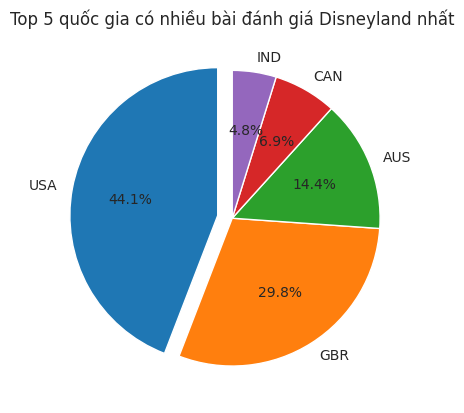

=> Nơi có nhiều lượt đánh giá về Disneyland nhất là: USA


In [ ]:
# Top 5 quốc gia có nhiều bài đánh giá Disneyland nhất

top5_locations = df['Reviewer_Location'].value_counts().iloc[:5]
explode = (0.1, 0, 0, 0, 0)
plt.pie(top5_locations.values, labels=top5_locations.index, autopct='%1.1f%%', startangle=90, explode=explode)
plt.title('Top 5 quốc gia có nhiều bài đánh giá Disneyland nhất')
plt.savefig(os.path.join(img_path, 'top5_locations.jpg'))
plt.show()

max_reviewer_location = df['Reviewer_Location'].value_counts().index[0]
print(f'=> Nơi có nhiều lượt đánh giá về Disneyland nhất là: {max_reviewer_location}')

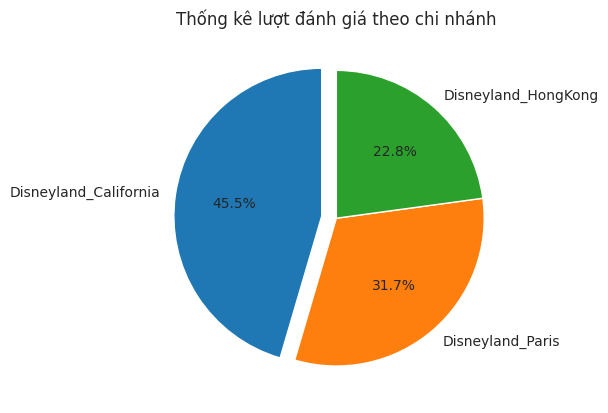

=> Chi nhánh có nhiều lượt đánh giá nhất là: Disneyland_California


In [ ]:
# Thống kê lượt đánh giá theo chi nhánh

branch_counts = df['Branch'].value_counts()
explode = (0.1, 0, 0)
plt.pie(branch_counts, labels=branch_counts.index, autopct='%1.1f%%', startangle=90, explode=explode)
plt.title('Thống kê lượt đánh giá theo chi nhánh')
plt.savefig(os.path.join(img_path, 'branch_pie.jpg'))
plt.show()

max_branch = df['Branch'].value_counts().index[0]
print(f'=> Chi nhánh có nhiều lượt đánh giá nhất là: {max_branch}')

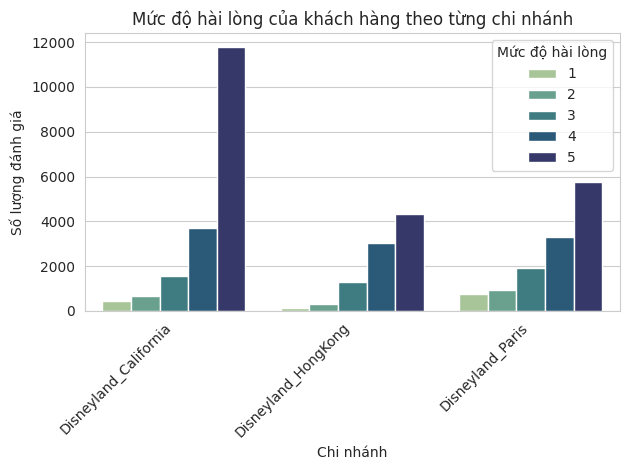

=> Chi nhánh có số lượng khách hàng đánh giá không hài lòng nhiều nhất là: Disneyland_Paris
=> Chi nhánh có số lượng khách hàng đánh giá 5 rất hài lòng nhiều nhất là: Disneyland_California
=> Chi nhánh có số lượng khách hàng đánh giá từ tương đối hài lòng trở xuống nhiều nhất là: Disneyland_Paris


In [ ]:
# Đánh giá mức độ hài lòng theo từng chi nhánh

branch_rating_counts = df.groupby(['Branch', 'Rating'])['Review_ID'].count().reset_index(name='Count')
branch_rating_counts = branch_rating_counts.sort_values(['Branch', 'Count'], ascending=[True, False])

sns.barplot(x='Branch', y='Count', hue='Rating', data=branch_rating_counts, palette='crest')
plt.title('Mức độ hài lòng của khách hàng theo từng chi nhánh')
plt.xlabel('Chi nhánh')
plt.ylabel('Số lượng đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mức độ hài lòng')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'branch_rating_counts.jpg'))
plt.show()

max_1_rating_branch = branch_rating_counts[branch_rating_counts['Rating'] == 1].sort_values('Count', ascending=False).iloc[0]['Branch']
print(f'=> Chi nhánh có số lượng khách hàng đánh giá không hài lòng nhiều nhất là: {max_1_rating_branch}')

max_5_rating_branch = branch_rating_counts[branch_rating_counts['Rating'] == 5].sort_values('Count', ascending=False).iloc[0]['Branch']
print(f'=> Chi nhánh có số lượng khách hàng đánh giá 5 rất hài lòng nhiều nhất là: {max_5_rating_branch}')


low_rating_counts = branch_rating_counts[branch_rating_counts['Rating'] < 4]
max_low_rating_branch = low_rating_counts.groupby('Branch')['Count'].sum().idxmax()
print(f'=> Chi nhánh có số lượng khách hàng đánh giá từ tương đối hài lòng trở xuống nhiều nhất là: {max_low_rating_branch}')

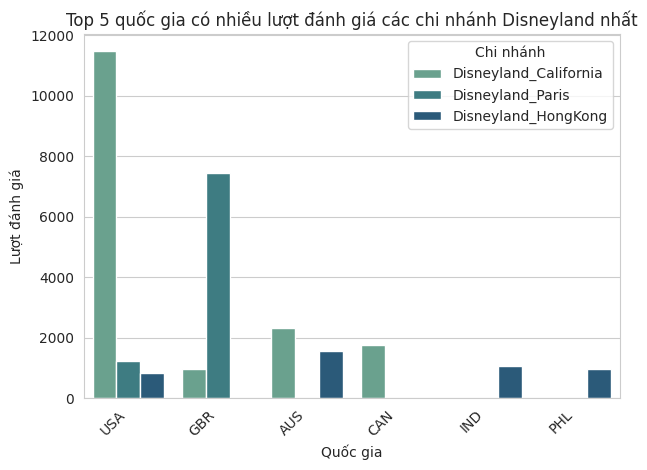

=> Disneyland thu hút nhiều lượt khách đến từ Mỹ và Anh nhất !
=> Du khách có xu hướng đến các chi nhánh gần họ nhất!
=> Disneyland phổ biến ở các quốc gia phương Tây nhiều nhất !


In [ ]:
# Top 5 quốc gia có nhiều lượt đánh giá các chi nhánh Disneyland nhất

location_branch_counts = df.groupby(['Reviewer_Location', 'Branch'])['Review_ID'].count().reset_index(name='Count')
location_branch_counts = location_branch_counts.sort_values('Count', ascending=False).iloc[:10]

sns.barplot(x='Reviewer_Location', y='Count', hue='Branch', data=location_branch_counts, palette='crest')
plt.title('Top 5 quốc gia có nhiều lượt đánh giá các chi nhánh Disneyland nhất')
plt.xlabel('Quốc gia')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chi nhánh')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'top5_location_branch_counts.jpg'))
plt.show()

print('=> Disneyland thu hút nhiều lượt khách đến từ Mỹ và Anh nhất !')
print('=> Du khách có xu hướng đến các chi nhánh gần họ nhất!')
print('=> Disneyland phổ biến ở các quốc gia phương Tây nhiều nhất !')


<ipython-input-22-1f8b655b989e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year_Month'].dt.year


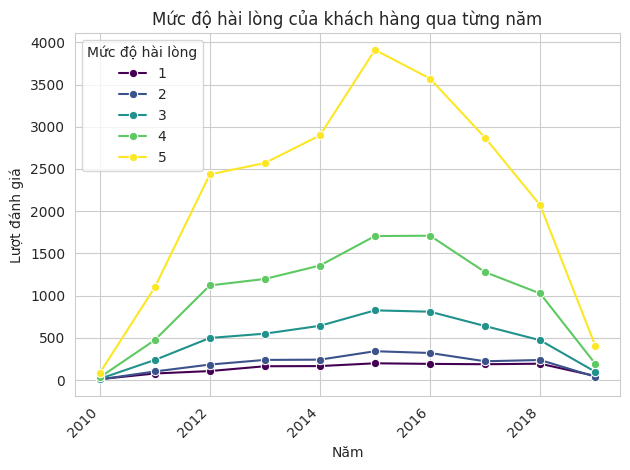

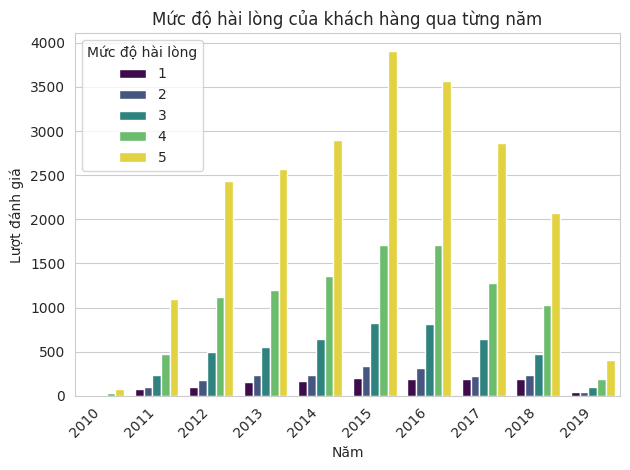

In [ ]:
# Mức độ hài lòng của khách hàng qua từng năm

df['Year'] = df['Year_Month'].dt.year
year_rating_counts = df.groupby(['Year', 'Rating'])['Review_ID'].count().reset_index(name='Count')

sns.lineplot(x='Year', y='Count', hue='Rating', data=year_rating_counts, palette='viridis', marker='o')
plt.title('Mức độ hài lòng của khách hàng qua từng năm')
plt.xlabel('Năm')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mức độ hài lòng')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'year_rating_counts_lineplot.jpg'))
plt.show()

sns.barplot(x='Year', y='Count', hue='Rating', data=year_rating_counts, palette='viridis')
plt.title('Mức độ hài lòng của khách hàng qua từng năm')
plt.xlabel('Năm')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mức độ hài lòng')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'year_rating_counts_barplot.jpg'))
plt.show()

# - Lượt đánh giá tăng dần qua các năm, cho thấy Disneyland ngày càng thu hút nhiều khách hàng hơn.
# - Mức độ hài lòng cao (rating 4 và 5) luôn chiếm đa số, cho thấy Disneyland mang đến trải nghiệm tốt cho khách hàng.
# - Tuy nhiên, cần chú ý đến lượt đánh giá thấp (rating 1 và 2) cũng có xu hướng tăng nhẹ, Disneyland cần xem xét và cải thiện các vấn đề để duy trì và nâng cao chất lượng dịch vụ.


<ipython-input-23-41e736b0e912>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Year_Month'].dt.month


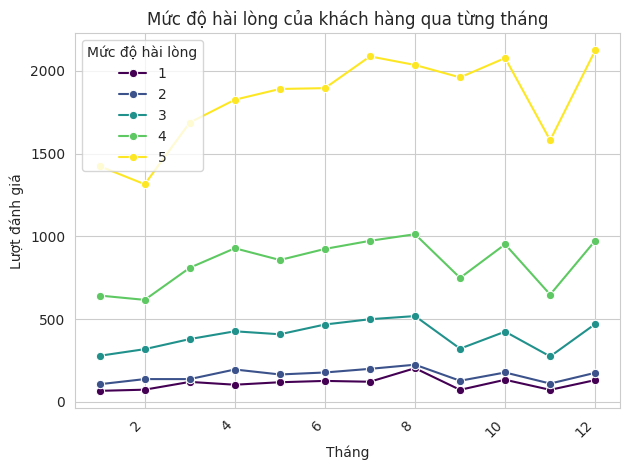

Nhìn chung, số lượng đánh giá có xu hướng tăng từ tháng 1 đến tháng 7 và sau đó giảm dần từ tháng 8 đến tháng 12.
Mức độ hài lòng cao nhất (5) có xu hướng đạt đỉnh vào khoảng tháng 6 và tháng 7, cho thấy mùa hè là thời điểm khách hàng có trải nghiệm tốt nhất tại Disneyland
Mức độ không hài lòng (1) có xu hướng thấp trong suốt cả năm, nhưng có thể tăng nhẹ vào các tháng cao điểm như tháng 6 và tháng 7.


In [ ]:
# Mức độ hài lòng qua từng tháng

df['Month'] = df['Year_Month'].dt.month
month_rating_counts = df.groupby(['Month', 'Rating'])['Review_ID'].count().reset_index(name='Count')

sns.lineplot(x='Month', y='Count', hue='Rating', data=month_rating_counts, palette='viridis', marker='o')
plt.title('Mức độ hài lòng của khách hàng qua từng tháng')
plt.xlabel('Tháng')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mức độ hài lòng')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'month_rating_counts.jpg'))
plt.show()

print('Nhìn chung, số lượng đánh giá có xu hướng tăng từ tháng 1 đến tháng 7 và sau đó giảm dần từ tháng 8 đến tháng 12.')
print('Mức độ hài lòng cao nhất (5) có xu hướng đạt đỉnh vào khoảng tháng 6 và tháng 7, cho thấy mùa hè là thời điểm khách hàng có trải nghiệm tốt nhất tại Disneyland')
print('Mức độ không hài lòng (1) có xu hướng thấp trong suốt cả năm, nhưng có thể tăng nhẹ vào các tháng cao điểm như tháng 6 và tháng 7.')


<ipython-input-24-b89cce8291fa>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Count', data=month_review_counts, palette='viridis')


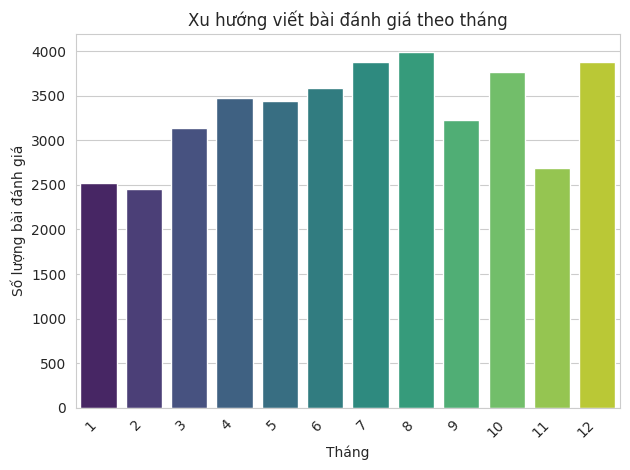

=> Số lượng bài đánh giá có xu hướng tăng cao vào các tháng hè (6, 7, 8) và các tháng lễ tết (12).
=> Điều này cho thấy nhu cầu du lịch và giải trí tăng cao trong các kỳ nghỉ.


In [ ]:
# Xu hướng viết bài đánh giá theo tháng

month_review_counts = df.groupby('Month')['Review_ID'].count().reset_index(name='Count')

sns.barplot(x='Month', y='Count', data=month_review_counts, palette='viridis')
plt.title('Xu hướng viết bài đánh giá theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng bài đánh giá')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(img_path, 'month_review_counts.jpg'))
plt.show()

print('=> Số lượng bài đánh giá có xu hướng tăng cao vào các tháng hè (6, 7, 8) và các tháng lễ tết (12).')
print('=> Điều này cho thấy nhu cầu du lịch và giải trí tăng cao trong các kỳ nghỉ.')


# Tiền xử lý dữ liệu (2)

#### Thuộc tính Review_Text

In [ ]:
# In thử 5 dòng dữ liệu

df['Review_Text'].head(5)

,Review_Text
0,If you've ever been to Disneyland anywhere you...
1,Its been a while since d last time we visit HK...
2,Thanks God it wasn t too hot or too humid wh...
3,HK Disneyland is a great compact park. Unfortu...
4,"the location is not in the city, took around 1..."


In [ ]:
# Lập hàm tiền xử lý chuỗi

def text_preprocessing(text):
  # Chuyển đổi chữ thường
  text = text.lower()
  # Loại bỏ HTML Tags
  text = strip_tags(text)
  # Loại bỏ các kí tự "lạ" (vd: emoji, ...)
  text = strip_non_alphanum(text)
  # Loại bỏ các số
  text = strip_numeric(text)
  # Loại bỏ dấu câu
  text = strip_punctuation(text)
  # Loại bỏ các từ có độ dài dưới 3 kí tự
  text = strip_short(text, 3)
  # Loại bỏ các từ dừng
  text = remove_stopwords(text)
  # Chuẩn hóa ngữ nghĩa theo thừ điển WordNet
  text = WordNetLemmatizer().lemmatize(text)
  # Loại bỏ các khoảng trắng thừa
  text = strip_multiple_whitespaces(text)
  return text

In [ ]:
# Bắt đầu tiền xử lý chuỗi

df['Review_Text'] = df['Review_Text'].apply(text_preprocessing)
df['Review_Text'].head(5)

<ipython-input-27-e83183e47e21>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Review_Text'] = df['Review_Text'].apply(text_preprocessing)


,Review_Text
0,disneyland disneyland hong kong similar layout...
1,time visit disneyland time stay tomorrowland a...
2,thanks god wasn hot humid visiting park big is...
3,disneyland great compact park unfortunately bi...
4,location city took hour kowlon kids like disne...


# Sentiment Analytics

#### VADER

In [ ]:
# Phân tích cảm xúc từ đoạn văn đánh giá bằng VADER

sia = SentimentIntensityAnalyzer()
df['vader_review_text_sentiments'] = df['Review_Text'].apply(lambda review: sia.polarity_scores(review))
df['compound']  = df['vader_review_text_sentiments'].apply(lambda x: x['compound'])

def get_sentiment(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['compound'].apply(get_sentiment)

df = df.drop(columns=['compound'])

df.head(10)

<ipython-input-28-eae2dc491061>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vader_review_text_sentiments'] = df['Review_Text'].apply(lambda review: sia.polarity_scores(review))
<ipython-input-28-eae2dc491061>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['compound']  = df['vader_review_text_sentiments'].apply(lambda x: x['compound'])
<ipython-input-28-eae2dc491061>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Year,Month,vader_review_text_sentiments,vader_sentiment
0,670772142,4,2019-04-01,AUS,disneyland disneyland hong kong similar layout...,Disneyland_HongKong,2019,4,"{'neg': 0.0, 'neu': 0.803, 'pos': 0.197, 'comp...",positive
1,670682799,4,2019-05-01,PHL,time visit disneyland time stay tomorrowland a...,Disneyland_HongKong,2019,5,"{'neg': 0.074, 'neu': 0.584, 'pos': 0.341, 'co...",positive
2,670623270,4,2019-04-01,ARE,thanks god wasn hot humid visiting park big is...,Disneyland_HongKong,2019,4,"{'neg': 0.064, 'neu': 0.514, 'pos': 0.422, 'co...",positive
3,670607911,4,2019-04-01,AUS,disneyland great compact park unfortunately bi...,Disneyland_HongKong,2019,4,"{'neg': 0.118, 'neu': 0.609, 'pos': 0.273, 'co...",positive
4,670607296,4,2019-04-01,GBR,location city took hour kowlon kids like disne...,Disneyland_HongKong,2019,4,"{'neg': 0.0, 'neu': 0.719, 'pos': 0.281, 'comp...",positive
5,670591897,3,2019-04-01,SGP,disney world disneyland anaheim tokyo disneyla...,Disneyland_HongKong,2019,4,"{'neg': 0.164, 'neu': 0.628, 'pos': 0.209, 'co...",positive
6,670585330,5,2019-04-01,IND,great place day won know obviously went daught...,Disneyland_HongKong,2019,4,"{'neg': 0.147, 'neu': 0.388, 'pos': 0.465, 'co...",positive
7,670574142,3,2019-03-01,MYS,think intro disney magic little ones attractio...,Disneyland_HongKong,2019,3,"{'neg': 0.054, 'neu': 0.804, 'pos': 0.142, 'co...",positive
8,670571027,2,2019-04-01,AUS,feel let place disneyland train fantastic past...,Disneyland_HongKong,2019,4,"{'neg': 0.163, 'neu': 0.614, 'pos': 0.223, 'co...",positive
9,670570869,5,2019-03-01,IND,talking disneyland disneyland childhood dreams...,Disneyland_HongKong,2019,3,"{'neg': 0.076, 'neu': 0.62, 'pos': 0.304, 'com...",positive


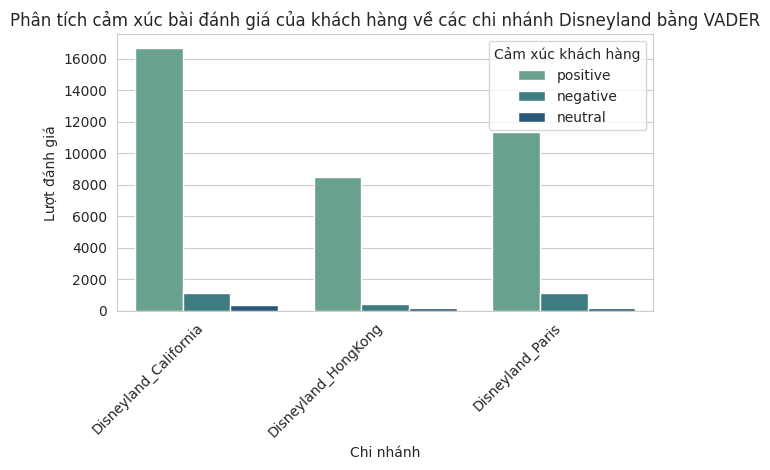

=> Chi nhánh Paris nhận được nhiều đánh giá negative nhất !


In [ ]:
# Phân tích cảm xúc bài đánh giá của khách hàng về các chi nhánh bằng VADER

branch_sentiment_counts = df.groupby(['Branch', 'vader_sentiment'])['Review_ID'].count().reset_index(name='Count')
branch_sentiment_counts = branch_sentiment_counts.sort_values(['Branch', 'Count'], ascending=[True, False])

sns.barplot(x='Branch', y='Count', hue='vader_sentiment', data=branch_sentiment_counts, palette='crest')
plt.title('Phân tích cảm xúc bài đánh giá của khách hàng về các chi nhánh Disneyland bằng VADER')
plt.xlabel('Chi nhánh')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cảm xúc khách hàng')
plt.tight_layout()
plt.show()

print('=> Chi nhánh Paris nhận được nhiều đánh giá negative nhất !')

#### TextBlob

In [ ]:
# Phân tích cảm xúc đánh giá bằng TextBlob

df['textblob_polarity'] = df['Review_Text'].apply(lambda review: TextBlob(review).sentiment.polarity)
df['textblob_subjectivity'] = df['Review_Text'].apply(lambda review: TextBlob(review).sentiment.subjectivity)

def get_textblob_sentiment(polarity):
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['textblob_sentiment'] = df['textblob_polarity'].apply(get_textblob_sentiment)

df['textblob_sentiment'].head(10)

,textblob_sentiment
0,positive
1,positive
2,positive
3,positive
4,positive
5,negative
6,positive
7,positive
8,negative
9,positive


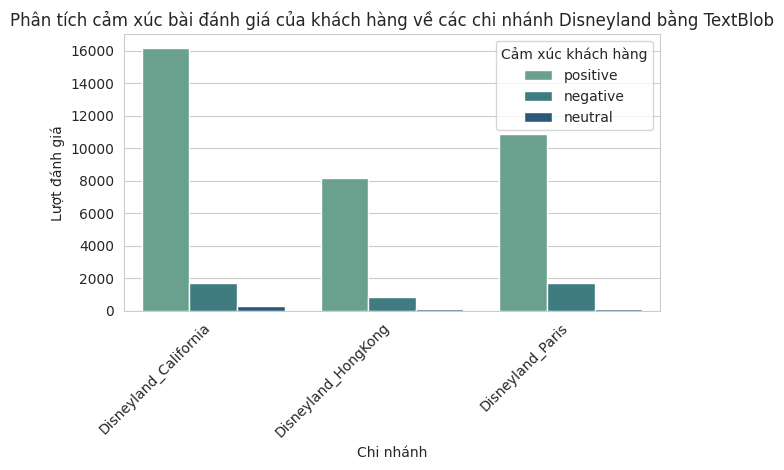

In [ ]:
# Phân tích cảm xúc bài đánh giá của khách hàng về các chi nhánh bằng TextBlob

branch_sentiment_counts = df.groupby(['Branch', 'textblob_sentiment'])['Review_ID'].count().reset_index(name='Count')
branch_sentiment_counts = branch_sentiment_counts.sort_values(['Branch', 'Count'], ascending=[True, False])

sns.barplot(x='Branch', y='Count', hue='textblob_sentiment', data=branch_sentiment_counts, palette='crest')
plt.title('Phân tích cảm xúc bài đánh giá của khách hàng về các chi nhánh Disneyland bằng TextBlob')
plt.xlabel('Chi nhánh')
plt.ylabel('Lượt đánh giá')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cảm xúc khách hàng')
plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu (3)

In [ ]:
# Mapping sentimens sang số nguyên

sentiment_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}

df['vader_sentiment'] = df['vader_sentiment'].map(sentiment_mapping)
df['textblob_sentiment'] = df['textblob_sentiment'].map(sentiment_mapping)

In [ ]:
# Khởi tạo nhãn

classes = ['negative', 'neutral', 'positive']
classes

['negative', 'neutral', 'positive']

<ipython-input-51-099e6f0c6342>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(classes)
<ipython-input-51-099e6f0c6342>:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(classes)


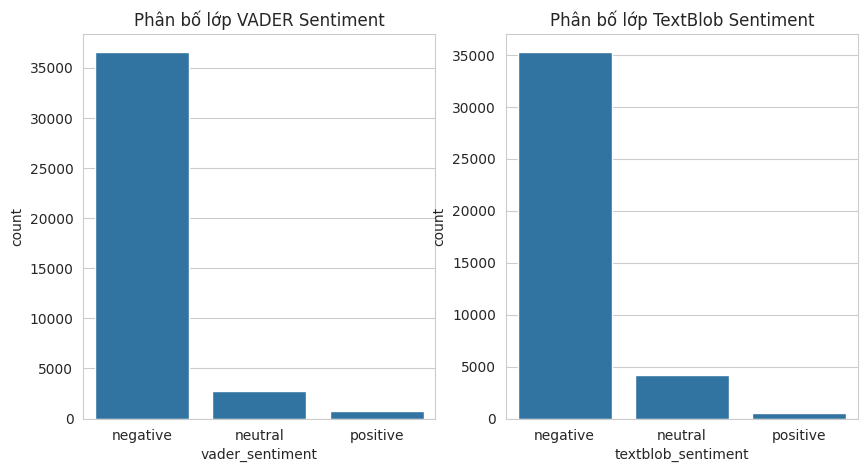

In [ ]:
# Kiểm tra mất cân bằng lớp

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x='vader_sentiment', data=df, order=df['vader_sentiment'].value_counts().index, ax=axes[0])
axes[0].set_title('Phân bố lớp VADER Sentiment')
axes[0].set_xticklabels(classes)

sns.countplot(x='textblob_sentiment', data=df, order=df['textblob_sentiment'].value_counts().index, ax=axes[1])
axes[1].set_title('Phân bố lớp TextBlob Sentiment')
axes[1].set_xticklabels(classes)

plt.show()

In [ ]:
# Tái cân bằng lớp
df_vader = df.copy()
df_textblob = df.copy()

rus = RandomUnderSampler(random_state=42)
df_vader, df_vader['vader_sentiment'] = rus.fit_resample(df_vader, df_vader['vader_sentiment'])
df_textblob, df_textblob['textblob_sentiment'] = rus.fit_resample(df_textblob, df_textblob['textblob_sentiment'])

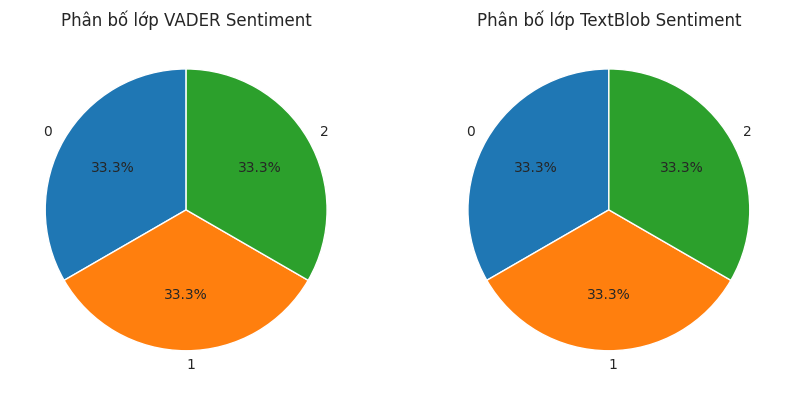

In [ ]:
# Kiểm tra lại cân bằng lớp

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

vader_sentiment_counts = df_vader['vader_sentiment'].value_counts()
axes[0].pie(vader_sentiment_counts.values, labels=vader_sentiment_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Phân bố lớp VADER Sentiment')

textblob_sentiment_counts = df_textblob['textblob_sentiment'].value_counts()
axes[1].pie(textblob_sentiment_counts.values, labels=textblob_sentiment_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Phân bố lớp TextBlob Sentiment')

plt.show()

# Xây dựng & đào tạo mô hình phân loại

==== VADER_SENTIMENT ====
BernoulliNB() 0.5985915492957746
              precision    recall  f1-score   support

           0       0.74      0.49      0.59       146
           1       0.48      0.83      0.61       139
           2       0.77      0.48      0.59       141

    accuracy                           0.60       426
   macro avg       0.66      0.60      0.60       426
weighted avg       0.67      0.60      0.60       426

Time for fit: 0.08 sec.


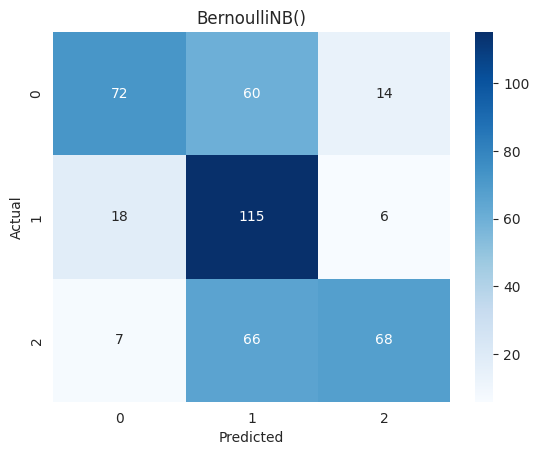

GaussianNB() 0.528169014084507
              precision    recall  f1-score   support

           0       0.55      0.42      0.48       146
           1       0.45      0.65      0.53       139
           2       0.65      0.51      0.57       141

    accuracy                           0.53       426
   macro avg       0.55      0.53      0.53       426
weighted avg       0.55      0.53      0.53       426

Time for fit: 0.05 sec.


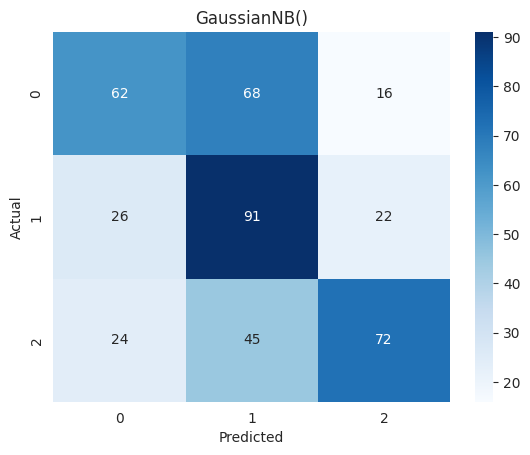

DecisionTreeClassifier() 0.6126760563380281
              precision    recall  f1-score   support

           0       0.60      0.50      0.54       146
           1       0.59      0.63      0.61       139
           2       0.64      0.71      0.67       141

    accuracy                           0.61       426
   macro avg       0.61      0.61      0.61       426
weighted avg       0.61      0.61      0.61       426

Time for fit: 0.57 sec.


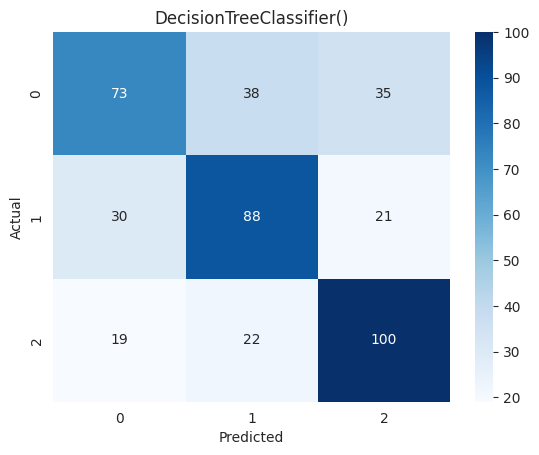

RandomForestClassifier() 0.7136150234741784
              precision    recall  f1-score   support

           0       0.73      0.63      0.68       146
           1       0.64      0.69      0.66       139
           2       0.77      0.82      0.80       141

    accuracy                           0.71       426
   macro avg       0.71      0.71      0.71       426
weighted avg       0.72      0.71      0.71       426

Time for fit: 1.75 sec.


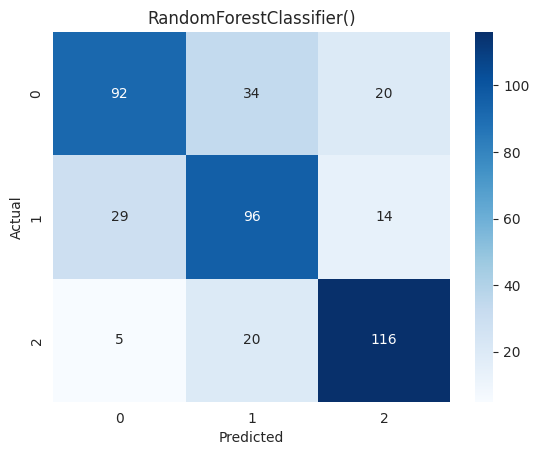

LogisticRegression() 0.715962441314554
              precision    recall  f1-score   support

           0       0.70      0.71      0.70       146
           1       0.61      0.67      0.64       139
           2       0.87      0.77      0.82       141

    accuracy                           0.72       426
   macro avg       0.72      0.72      0.72       426
weighted avg       0.72      0.72      0.72       426

Time for fit: 0.52 sec.


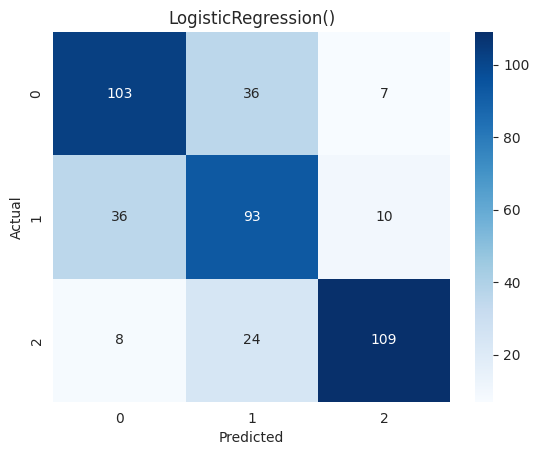

=> Best model: LogisticRegression() 0.715962441314554
==== TEXTBLOB_SENTIMENT ====
BernoulliNB() 0.6698113207547169
              precision    recall  f1-score   support

           0       0.76      0.51      0.61       114
           1       0.59      0.93      0.72       107
           2       0.75      0.58      0.65        97

    accuracy                           0.67       318
   macro avg       0.70      0.67      0.66       318
weighted avg       0.70      0.67      0.66       318

Time for fit: 0.04 sec.


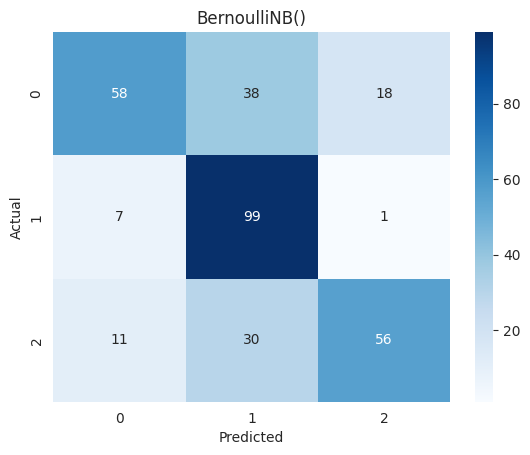

GaussianNB() 0.6320754716981132
              precision    recall  f1-score   support

           0       0.59      0.62      0.61       114
           1       0.71      0.61      0.66       107
           2       0.61      0.67      0.64        97

    accuracy                           0.63       318
   macro avg       0.64      0.63      0.63       318
weighted avg       0.64      0.63      0.63       318

Time for fit: 0.03 sec.


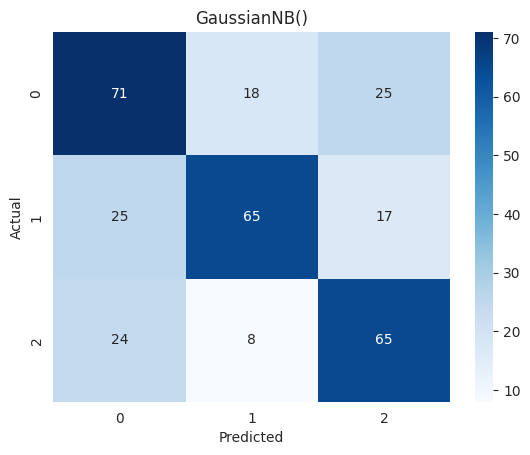

DecisionTreeClassifier() 0.6949685534591195
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       114
           1       0.81      0.76      0.78       107
           2       0.66      0.69      0.68        97

    accuracy                           0.69       318
   macro avg       0.70      0.70      0.70       318
weighted avg       0.70      0.69      0.70       318

Time for fit: 0.21 sec.


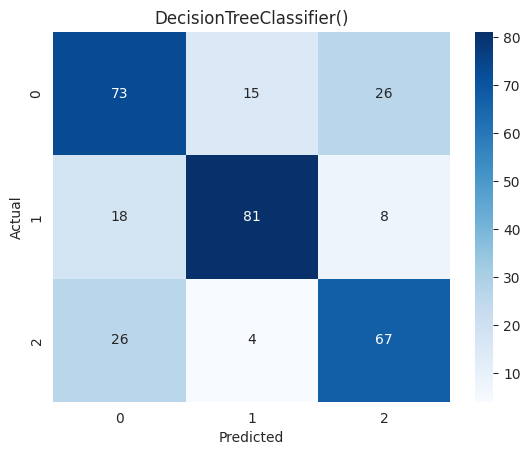

RandomForestClassifier() 0.7389937106918238
              precision    recall  f1-score   support

           0       0.72      0.63      0.67       114
           1       0.78      0.86      0.82       107
           2       0.71      0.73      0.72        97

    accuracy                           0.74       318
   macro avg       0.74      0.74      0.74       318
weighted avg       0.74      0.74      0.74       318

Time for fit: 0.78 sec.


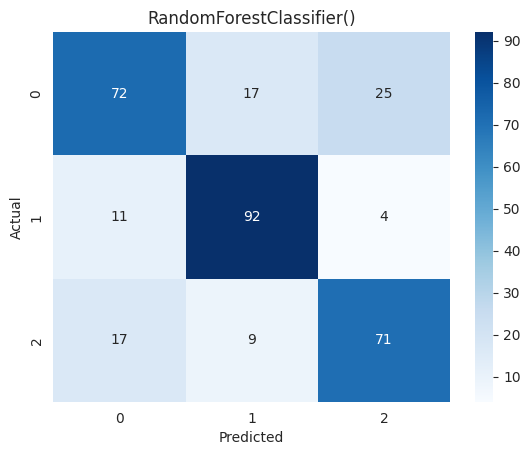

LogisticRegression() 0.779874213836478
              precision    recall  f1-score   support

           0       0.76      0.75      0.75       114
           1       0.76      0.82      0.79       107
           2       0.83      0.77      0.80        97

    accuracy                           0.78       318
   macro avg       0.78      0.78      0.78       318
weighted avg       0.78      0.78      0.78       318

Time for fit: 0.33 sec.


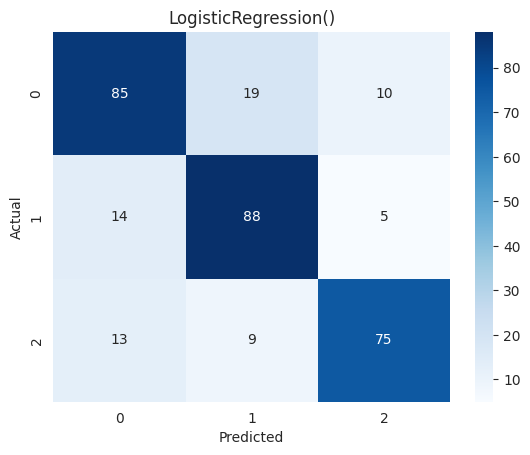

=> Best model: LogisticRegression() 0.779874213836478
=== VADER_SENTIMENT ===
Độ chính xác trung bình cho cả 4 thuật toán: 0.6338028169014084
Mô hình tốt nhất: LogisticRegression()
=== TEXTBLOB_SENTIMENT ===
Độ chính xác trung bình cho cả 4 thuật toán: 0.7031446540880502
Mô hình tốt nhất: LogisticRegression()


In [ ]:
sentiments = {
    'vader_sentiment': df_vader,
    'textblob_sentiment': df_textblob
}
models = [BernoulliNB(), GaussianNB(), DecisionTreeClassifier(), RandomForestClassifier(), LogisticRegression()]
test_size = .20
val_size = .10
mean_accuracy_per_sentiments = {}
accuracy_models = {}
best_models = {}
f1_score_models = {
    'vader_sentiment': {},
    'textblob_sentiment': {}
}
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=1000)

for name, data in sentiments.items():
  accuracy_models.clear()

  print('====', name.upper(), '====')

  # Hợp nhất tập x, y
  X = data['Review_Text']
  y = data[name]

  # Chia tập train, test, val tỉ lệ 70:20:10
  x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
  x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=val_size, random_state=42)

  # Vectơ hóa chuỗi đầu vào
  x_train_vectorized = vectorizer.fit_transform(x_train).toarray()
  x_test_vectorized = vectorizer.transform(x_test).toarray()
  x_val_vectorized = vectorizer.transform(x_val).toarray()

  # Xây dựng & đào tạo mô hình
  for model in models:

    # Bắt đầu đếm thời gian để fit mô hình
    start_time = time.time()

    # Đào tạo mô hình & dự đoán tập Test
    model.fit(x_train_vectorized, y_train)
    y_pred = model.predict(x_test_vectorized)

    # Tính độ chính xác giữa lớp dự đoán và lớp thực của tập Test
    acc = accuracy_score(y_test, y_pred)
    print(model, acc)
    accuracy_models[model] = acc

    # Tính & lưu chỉ số f1 score phục vụ trực quan hóa biểu đồ
    f1s = f1_score(y_test, y_pred, average='macro')
    f1_score_models[name].update({model: f1s})

    # Đánh giá f1_score các lớp & in thời gian fit mô hình
    print(classification_report(y_test, y_pred))
    print('Time for fit:', round(time.time() - start_time, 2), 'sec.')

    # Vẽ ma trận nhầm lẫn
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(model)
    plt.show()

  # In & lưu mô hình tốt nhất của một sentiment
  best_model = max(accuracy_models, key=accuracy_models.get)
  print('=> Best model:', best_model, accuracy_models[best_model])
  best_models[name] = (best_model, vectorizer)

  # Tính độ chính xác trung bình của một sentiment
  mean_accuracy_per_sentiments[name] = np.mean(list(accuracy_models.values()))

for idx, value in mean_accuracy_per_sentiments.items():
  print(f'=== {idx.upper()} ===')
  print(f'Độ chính xác trung bình cho cả 4 thuật toán: {value}')
  print(f'Mô hình tốt nhất: {best_models[idx][0]}')


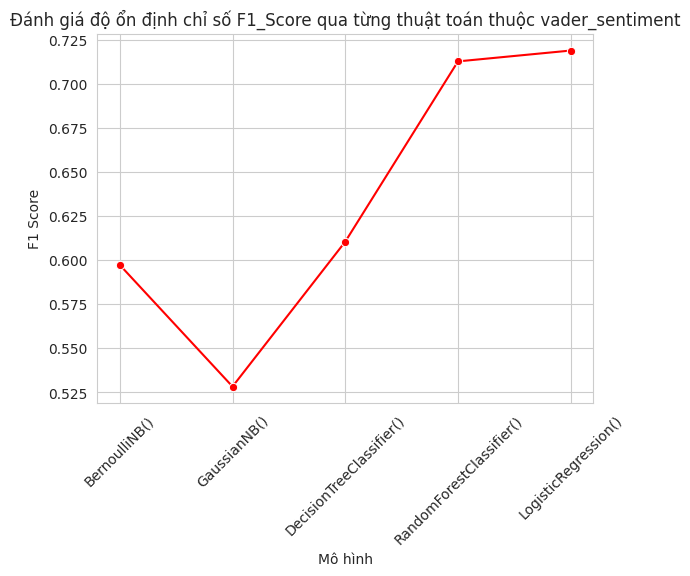

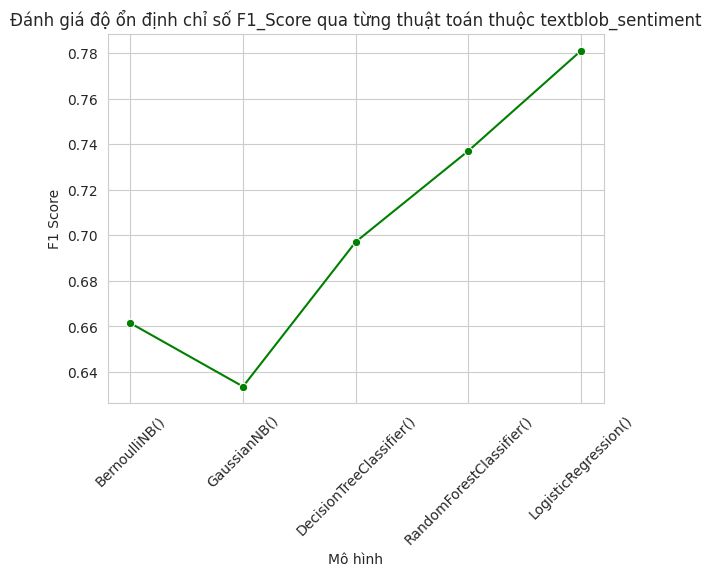

=> Hầu hết các thuật toán ở cả 2 sentiment đều cho chỉ số F1 Score khá thấp !
 Do một số dữ liệu đã bị lược bỏ để đảm bảo cân bằng lớp !
=> Phương pháp hồi quy Logistic & cây quyết định có xử lý khá tốt (khoảng 70%) trên cả 2 tập VADER và TextBlob !


In [ ]:
# Trực quan hóa chỉ số F1_score

colors = ['r', 'g']
for i, (name, _) in enumerate(sentiments.items()):
  my_sentiment = f1_score_models[name]

  # Convert sang pandas
  data = {
      'Model': list(my_sentiment.keys()),
      'F1 Score': list(my_sentiment.values()),
      'Index': range(len(my_sentiment))
  }
  data = pd.DataFrame(data)

  # Sắp xếp giảm dần theo cột 'F1 Score'
  data = data.sort_values(by='F1 Score', ascending=False)

  # Vẽ biểu đồ lineplot đánh giá độ ổn định chỉ số F1_Score của từng thuật toán
  sns.lineplot(x='Index', y='F1 Score', data=data, marker='o', color=colors[i])
  plt.title(f'Đánh giá độ ổn định chỉ số F1_Score qua từng thuật toán thuộc {name}')
  plt.xlabel('Mô hình')
  plt.ylabel('F1 Score')
  plt.xticks(ticks=data['Index'], labels=data['Model'], rotation=45)
  plt.savefig(os.path.join(img_path, f'f1_score_{name}.jpg'))
  plt.show()

print('=> Hầu hết các thuật toán ở cả 2 sentiment đều cho chỉ số F1 Score khá thấp !\n Do một số dữ liệu đã bị lược bỏ để đảm bảo cân bằng lớp !')
print('=> Phương pháp hồi quy Logistic & cây quyết định có xử lý khá tốt (khoảng 70%) trên cả 2 tập VADER và TextBlob !')


In [ ]:
# Lưu mô hình tốt nhất

for name, model_and_vect in best_models.items():
  with open(os.path.join(model_path, f'{name}_model.pkl'), 'wb') as f:
    pickle.dump(model_and_vect, f)

# Dự đoán mẫu dữ liệu mới

In [ ]:
!ls {model_path}

textblob_sentiment_model.pkl  vader_sentiment_model.pkl


In [ ]:
# Nạp mô hình đã Train

with open(os.path.join(model_path, 'vader_sentiment_model.pkl'), 'rb') as f:
  vader_model, vader_vect = pickle.load(f)

with open(os.path.join(model_path, 'textblob_sentiment_model.pkl'), 'rb') as f:
  textblob_model, textblob_vect = pickle.load(f)

Nhập phản hồi khách hàng: The difference between Disneyland of the 1980s and 2020s is palpable. It has become an expensive endurance test, not helped by the lack of shelter from the sun. Even with a genie+ pass and arriving for "ropes drop," we still had to queue for over an hour for our first ride. You have to buy an additional ticket for $25 each to join the lightning lane a Rise of the Resistance. Overall - greedy, overcrowded and unpleasant. I have no idea how people manage to do Disney with young kids!
=== VADER proba ===
negative: 0.42
neutral: 0.33
positive: 0.25
=== TextBlob proba ===
negative: 0.42
neutral: 0.33
positive: 0.25
=> VADER: negative
=> TextBlob: negative


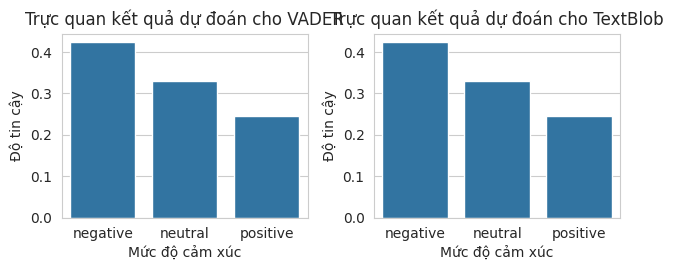



Nhập phản hồi khách hàng: Wow! Where to begin. Great place for the entire family. Total themeed emersion in the different lands and on attractions. Each land and attraction tells a different story. We went to both Disneyland (DL) and Disney California Adventure Park (DCA). Two days in each park is ideal so you can see everything each park has to offer. In DL My 8 and 10 year old loved Rise of the Resistance and Smugglers Run in Star Wars Galaxy Edge. In DCA I would not miss Radiator Springs Racers, Incredicoaster and Guardians of the Galaxy Mission Breakout. All and all so much fun. A lot of walking so where comfortable shoes.
=== VADER proba ===
negative: 0.13
neutral: 0.13
positive: 0.74
=== TextBlob proba ===
negative: 0.13
neutral: 0.13
positive: 0.74
=> VADER: positive
=> TextBlob: positive


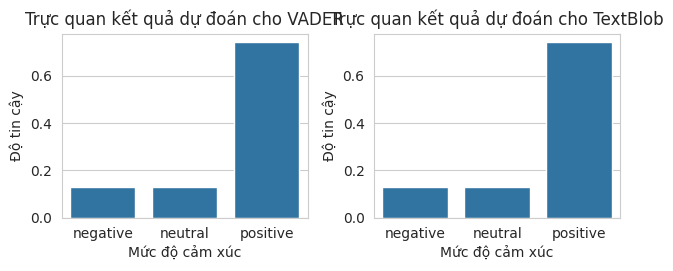



Nhập phản hồi khách hàng: exit


In [ ]:
while True:
  input_text = input('Nhập phản hồi khách hàng: ')

  if input_text == 'exit':
    break

  # Tiền xử lý chuỗi
  input_text_preprocessed = text_preprocessing(input_text)

  # Vectơ hóa chuỗi
  vader_input_vectorized = vader_vect.transform([input_text_preprocessed])
  textblob_input_vectorized = textblob_vect.transform([input_text_preprocessed])

  # Tính xác suất từng lớp
  vader_proba = vader_model.predict_proba(vader_input_vectorized)[0]
  textblob_proba = textblob_model.predict_proba(textblob_input_vectorized)[0]

  # In xác suất từng lớp
  print('=== VADER proba ===')
  for i, class_name in enumerate(classes):
    print(f'{class_name}: {vader_proba[i]:.2f}')

  print('=== TextBlob proba ===')
  for i, class_name in enumerate(classes):
    print(f'{class_name}: {textblob_proba[i]:.2f}')

  # Dự đoán các kết quả cuối cùng
  vader_prediction = vader_model.predict(vader_input_vectorized)
  textblob_prediction = textblob_model.predict(textblob_input_vectorized)

  # In các kết quả dự đoán cuối cùng
  print('=> VADER:', classes[vader_prediction[0]])
  print('=> TextBlob:', classes[textblob_prediction[0]])

  # Vẽ biểu đồ cho VADER
  plt.subplot(2, 2, 1)
  sns.barplot(x=classes, y=vader_proba)
  plt.title('Trực quan kết quả dự đoán cho VADER')
  plt.xlabel('Mức độ cảm xúc')
  plt.ylabel('Độ tin cậy')

  # Vẽ biểu đồ cho TextBlob
  plt.subplot(2, 2, 2)
  sns.barplot(x=classes, y=textblob_proba)
  plt.title('Trực quan kết quả dự đoán cho TextBlob')
  plt.xlabel('Mức độ cảm xúc')
  plt.ylabel('Độ tin cậy')

  plt.tight_layout()
  plt.savefig(os.path.join(img_path, 'du_doan_moi.jpg'))

  plt.show()

  print('\n')